# Customer Cartography
## Retail Customer Segmentation by Purchase and Cancellation Activity

This notebook explores customer purchasing and cancellation behavior using 12 features. These describe purchase recency, frequency, line counts, product variety, quantities, purchase value, average order value, and cancellation activity.

The goal is to identify interpretable customer segments and understand how unusually large transactions influence the results. SQL is used to prepare the customer features, Python is used to develop and evaluate the segments, and Power BI is used to communicate the findings.

## Data and scope

This project uses the [Online Retail dataset from the UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/352/online+retail), containing transactions from a UK-based online retailer.

The analysis covers transactions from December 1, 2010, through December 9, 2011, with recency measured as of December 10, 2011. The starting feature table contains 4,334 purchasing customers.

The analysis includes the three RFM measures:

Recency: Days since the customer's most recent qualifying purchase.

Frequency: Number of distinct qualifying purchase invoices.

Monetary value: Total qualifying purchase spending before cancellations, measured in GBP.

Because additional purchase and cancellation features also influence clustering, this is a broader behavioral analysis rather than an RFM-only segmentation. Purchase value is not net revenue, and cancellation amounts have not been verified as matched refunds.

## Analysis workflow

Features are standardized, principal component analysis (PCA) reduces dimensionality, and candidate cluster solutions are evaluated using silhouette scores, cluster sizes, and customer profiles in their original units.

Before excluding customers, the analysis documents their distinguishing behaviors, the evidence supporting exclusion, and the remaining uncertainty. Unusual behavior or small cluster size alone does not justify removal. The original dataset is preserved for separate review, and the scaler, PCA, and clustering are refitted on the retained customers.

Two customers with exceptionally large purchases and equal or nearly equal cancellation totals are excluded after review, leaving 4,332 customers. This is an analytical scope decision, not a finding that their records are errors.

The subsequent analysis applies log1p to eleven features, leaves recency unlogged, and standardizes all twelve features before refitting PCA and KMeans. Four clusters are selected for interpretable behavioral detail, although two clusters achieve the highest tested silhouette score.

The selected model is checked across random initializations and an alternative treatment of repeated source records. Final customer assignments and summary tables are validated and exported for Power BI.

These checks assess consistency under the conditions tested. They do not establish future stability or prove that proposed business actions will be effective.

## Running this notebook

Place these SQL-generated input files in the same folder as the notebook:

customer_features.csv: the primary customer feature table.

customer_features_one_per_group.csv: the alternative feature table used to assess sensitivity to repeated source records.

The notebook requires pandas, NumPy, Matplotlib, seaborn, scikit-learn, and SciPy.

Start Jupyter with the project folder as the working directory, then run the notebook from top to bottom. Charts display within the notebook, and the final export cell saves validated customer and segment tables to the Exports folder.

## Data source citation

Chen, D. (2015). *Online Retail* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import adjusted_rand_score
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# load features table

customer_features = pd.read_csv(
    "customer_features.csv",
    dtype={"customer_id": "string"}
)

customer_features.head()

,customer_id,reference_date,first_purchase_date,last_purchase_date,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,first_cancellation_date,last_cancellation_date,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
0,12346,12/10/2011,1/18/2011 10:01,1/18/2011 10:01,326,1,1,1,74215,77183.60,77183.6000,1/18/2011 10:17,1/18/2011 10:17,1,1,1,74215,77183.6
1,12347,12/10/2011,12/7/2010 14:57,12/7/2011 15:52,3,7,182,103,2458,4310.00,615.7143,NaN,NaN,0,0,0,0,0.0
2,12348,12/10/2011,12/16/2010 19:09,9/25/2011 13:13,76,4,27,21,2332,1437.24,359.3100,NaN,NaN,0,0,0,0,0.0
3,12349,12/10/2011,11/21/2011 9:51,11/21/2011 9:51,19,1,72,72,630,1457.55,1457.5500,NaN,NaN,0,0,0,0,0.0
4,12350,12/10/2011,2/2/2011 16:01,2/2/2011 16:01,311,1,16,16,196,294.40,294.4000,NaN,NaN,0,0,0,0,0.0


In [3]:
# validate the primary customer feature table

assert len(customer_features) == 4334, "Unexpected starting customer count."
assert customer_features["customer_id"].notna().all(), "Missing customer IDs."
assert customer_features["customer_id"].is_unique, "Duplicate customer IDs."

model_columns = [
    "recency_days",
    "purchase_frequency",
    "purchase_line_count",
    "distinct_products",
    "purchase_quantity",
    "purchase_value",
    "average_order_value",
    "cancellation_frequency",
    "cancellation_line_count",
    "distinct_cancelled_products",
    "cancelled_quantity",
    "cancellation_value"
]

missing_columns = set(model_columns) - set(customer_features.columns)
assert not missing_columns, f"Missing features: {sorted(missing_columns)}"

model_input = customer_features[model_columns]

assert all(
    pd.api.types.is_numeric_dtype(model_input[column])
    for column in model_columns
), "Model features must be numeric."

assert np.isfinite(model_input.to_numpy(dtype=float)).all(), (
    "Model features contain missing or infinite values."
)
assert (model_input >= 0).all().all(), "Model features contain negative values."

print("Input validation passed: 4,334 customers and 12 numeric features.")

Input validation passed: 4,334 customers and 12 numeric features.


In [4]:
# select the validated model features

features = customer_features[model_columns].copy()

features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4334 entries, 0 to 4333
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   recency_days                 4334 non-null   int64  
 1   purchase_frequency           4334 non-null   int64  
 2   purchase_line_count          4334 non-null   int64  
 3   distinct_products            4334 non-null   int64  
 4   purchase_quantity            4334 non-null   int64  
 5   purchase_value               4334 non-null   float64
 6   average_order_value          4334 non-null   float64
 7   cancellation_frequency       4334 non-null   int64  
 8   cancellation_line_count      4334 non-null   int64  
 9   distinct_cancelled_products  4334 non-null   int64  
 10  cancelled_quantity           4334 non-null   int64  
 11  cancellation_value           4334 non-null   float64
dtypes: float64(3), int64(9)
memory usage: 406.4 KB


In [5]:
# standardize features to mean 0 and variance 1 before clustering

scaler = StandardScaler()

scaled_df = pd.DataFrame(
    scaler.fit_transform(features),
    columns=features.columns,
    index=features.index
)

scaled_df.head()

,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
0,2.323928,-0.425192,-0.396671,-0.708248,14.482263,8.439119,42.631059,0.101498,-0.133659,-0.124120,43.869750,26.940073
1,-0.900791,0.360754,0.397313,0.487611,0.251478,0.256986,0.110395,-0.385649,-0.271714,-0.294407,-0.036768,-0.039042
2,-0.171984,-0.032219,-0.282618,-0.473766,0.226490,-0.065563,-0.031995,-0.385649,-0.271714,-0.294407,-0.036768,-0.039042
3,-0.741052,-0.425192,-0.085219,0.124164,-0.111050,-0.063283,0.577894,-0.385649,-0.271714,-0.294407,-0.036768,-0.039042
4,2.174174,-0.425192,-0.330872,-0.532387,-0.197120,-0.193879,-0.068042,-0.385649,-0.271714,-0.294407,-0.036768,-0.039042


In [6]:
# fit PCA and examine variance

pca_full = PCA()
pca_full.fit(scaled_df)

variance_original = pd.DataFrame({
    "components": np.arange(1, len(features.columns) + 1),
    "cumulative_variance": pca_full.explained_variance_ratio_.cumsum()
})

variance_original

,components,cumulative_variance
0,1,0.433527
1,2,0.691346
2,3,0.786916
3,4,0.868231
4,5,0.929807
5,6,0.957695
6,7,0.974355
7,8,0.983294
8,9,0.990566
9,10,0.996125


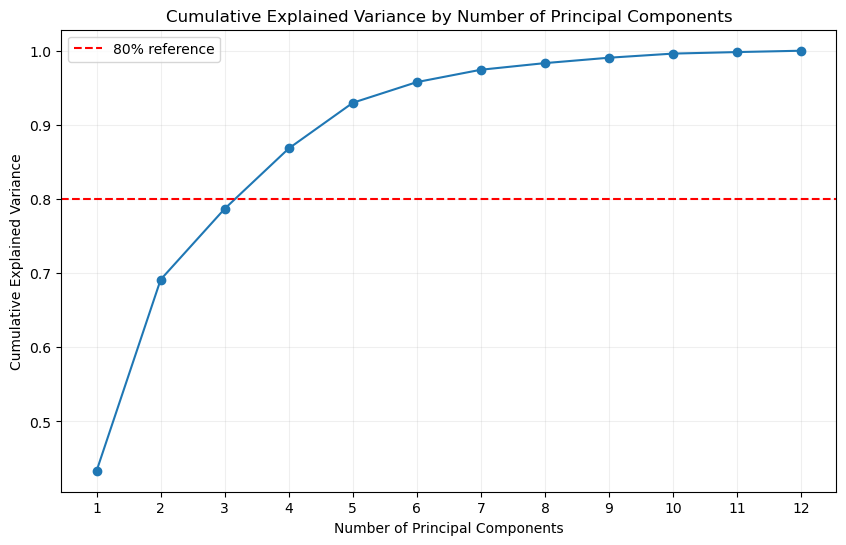

In [7]:
# plot cumulative explained variance to assess components to retain

plt.figure(figsize=(10, 6))
plt.plot(
    variance_original["components"],
    variance_original["cumulative_variance"],
    marker="o"
)
plt.xticks(variance_original["components"])
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Number of Principal Components")
plt.axhline(0.80, color="r", linestyle="--", label="80% reference")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [8]:
# retain four principal components explaining at least 80% of total variance

pca = PCA(n_components=4)
pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=features.index
)

pca_df.head()

,PC1,PC2,PC3,PC4
0,21.381503,63.108661,8.394141,-6.079676
1,0.377126,0.020216,-1.070745,-0.640889
2,-0.544231,0.227367,-0.345890,0.064802
3,-0.375534,0.376820,-0.445320,-0.731562
4,-1.186944,0.328364,0.785270,1.664882


In [9]:
# compare KMeans solutions with 2–10 clusters using inertia and silhouette scores

inertias_original = []
silhouettes_original = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(pca_data)

    inertias_original.append(model.inertia_)
    silhouettes_original.append(silhouette_score(pca_data, labels))

results_original = pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias_original,
    "silhouette_score": silhouettes_original
})

results_original

,k,inertia,silhouette_score
0,2,32495.412557,0.972552
1,3,21728.075143,0.926254
2,4,15907.603041,0.641940
3,5,12891.552953,0.470556
4,6,9981.230165,0.473553
5,7,8400.369819,0.485524
6,8,7028.032501,0.483799
7,9,6260.379280,0.484579
8,10,5476.740263,0.434006


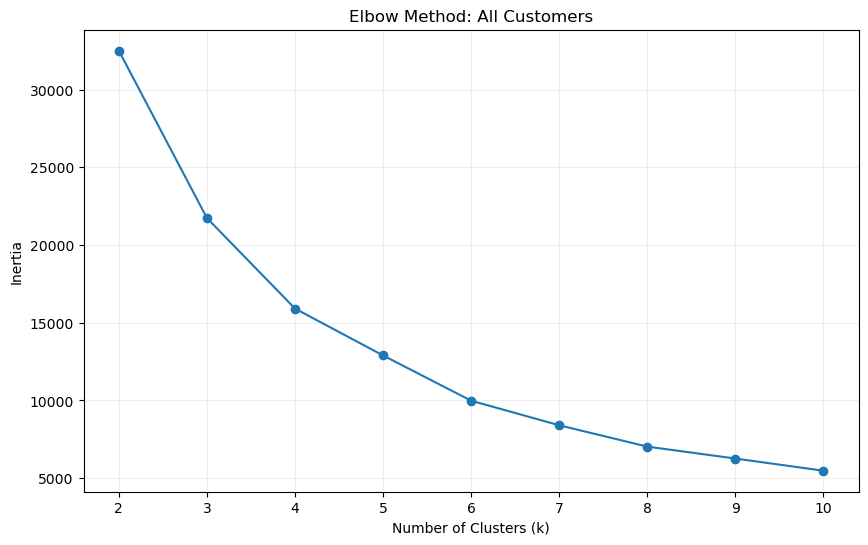

In [10]:
# plot inertia across cluster counts to look for an elbow suggesting a suitable k

plt.figure(figsize=(10, 6))
plt.plot(results_original["k"], results_original["inertia"], marker="o")
plt.xticks(results_original["k"])
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method: All Customers")
plt.grid(alpha=0.2)
plt.show()

In [11]:
# fit KMeans with three clusters and summarize customer counts and percentages in each cluster

kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_original = kmeans_original.fit_predict(pca_data)

sizes_original = (
    pd.Series(labels_original, name="cluster")
    .value_counts()
    .sort_index()
    .rename("customers")
    .to_frame()
)

sizes_original["percent"] = (
    sizes_original["customers"] / len(labels_original) * 100
).round(2)

sizes_original

,customers,percent
cluster,,
0,4315,99.56
1,2,0.05
2,17,0.39


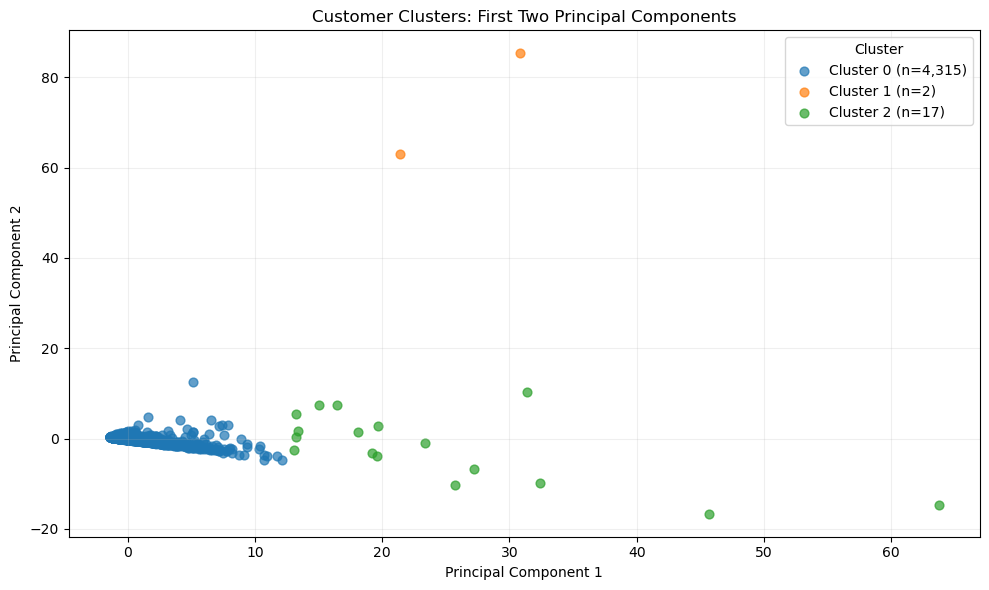

In [12]:
# visualize the three clusters using the first two principal components

plt.figure(figsize=(10, 6))

for cluster in sorted(np.unique(labels_original)):
    mask = labels_original == cluster
    plt.scatter(
        pca_data[mask, 0],
        pca_data[mask, 1],
        label=f"Cluster {cluster} (n={mask.sum():,})",
        alpha=0.7,
        s=40
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters: First Two Principal Components")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
# compare cluster sizes and original feature medians to investigate the two small clusters

review_original = features.copy()
review_original["cluster"] = labels_original

cluster_profile_original = sizes_original.join(
    review_original.groupby("cluster")[features.columns].median()
)

cluster_profile_original

,customers,percent,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
cluster,,,,,,,,,,,,,,
0,4315,99.56,52.0,2.0,41.0,35.0,377.0,663.61,289.8200,0.0,0.0,0.0,0.0,0.00
1,2,0.05,163.5,1.5,2.0,2.0,77606.0,122828.05,80709.9250,1.0,1.0,1.0,77605.0,122826.60
2,17,0.39,3.0,60.0,1637.0,636.0,57872.0,65039.62,1175.5176,10.0,39.0,20.0,434.0,1439.95


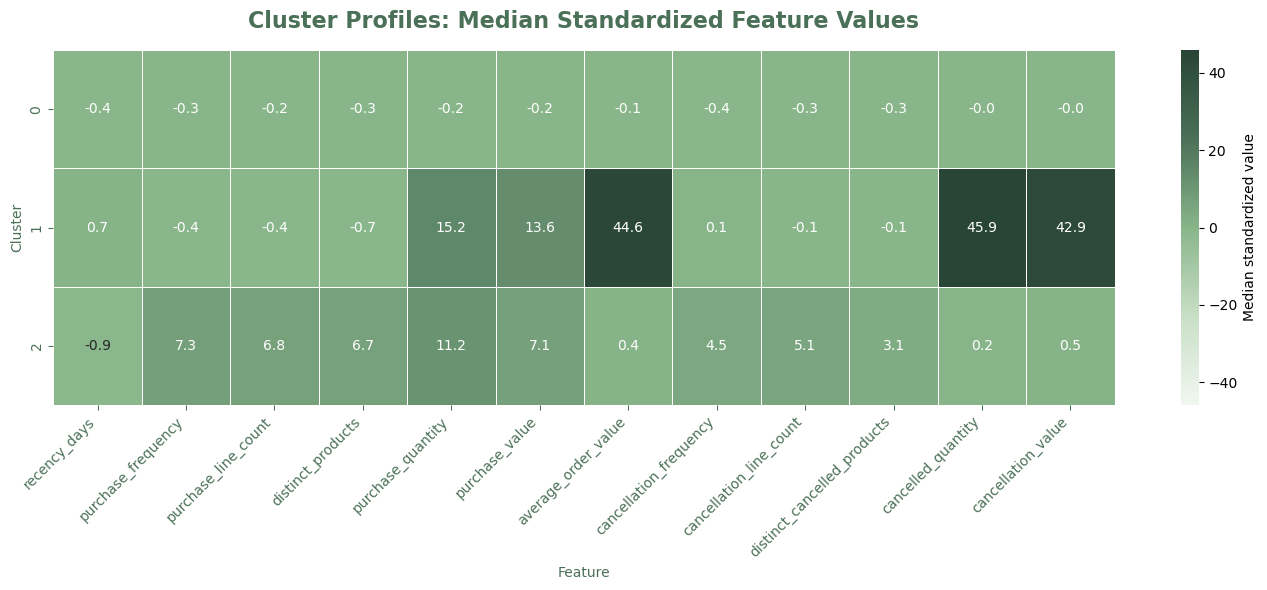

In [14]:
dashboard_greens = LinearSegmentedColormap.from_list(
    "dashboard_greens",
    ["#F1F7F0", "#C8DFC6", "#88B58A", "#4B7058", "#294535"]
)

# Cluster medians using features standardized across all customers
scaled_review_original = scaled_df.copy()
scaled_review_original["cluster"] = labels_original

heatmap_original = (
    scaled_review_original
    .groupby("cluster")[features.columns]
    .median()
)

color_limit_original = np.abs(heatmap_original.to_numpy()).max()

fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")

sns.heatmap(
    heatmap_original,
    cmap=dashboard_greens,
    vmin=-color_limit_original,
    vmax=color_limit_original,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Median standardized value"},
    ax=ax
)

ax.set_title(
    "Cluster Profiles: Median Standardized Feature Values",
    color="#4B7058",
    fontsize=16,
    fontweight="bold",
    pad=16
)
ax.set_xlabel("Feature", color="#4B7058")
ax.set_ylabel("Cluster", color="#4B7058")
ax.tick_params(axis="both", colors="#4B7058")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [15]:
# inspect the original customer records in the two-customer cluster

customer_review_original = customer_features.copy()
customer_review_original["cluster"] = labels_original

two_customer_review = customer_review_original.loc[
    customer_review_original["cluster"] == 1
]

two_customer_review.T

,0,3006
customer_id,12346,16446
reference_date,12/10/2011,12/10/2011
first_purchase_date,1/18/2011 10:01,5/18/2011 9:52
last_purchase_date,1/18/2011 10:01,12/9/2011 9:15
recency_days,326,1
purchase_frequency,1,2
purchase_line_count,1,3
distinct_products,1,3
purchase_quantity,74215,80997
purchase_value,77183.6,168472.5


### Review and exclusion of the two-customer cluster

Cluster 1 contains customers 12346 and 16446, whose unusually large purchases are accompanied by equal or nearly equal cancellation totals.

Customer 12346: Recorded one purchase of 74,215 units worth 77,183.60. A cancellation recorded 16 minutes later has identical quantity and value totals.

Customer 16446: Recorded two purchases totaling 80,997 units worth 168,472.50. Cancellation totals are 80,995 units and 168,469.60, leaving an aggregate difference of only 2 units and 2.90. The cancellation occurred 12 minutes after the last recorded purchase.

The model includes both purchase and cancellation features. These customers show extreme values in purchase quantity, purchase value, average order value, cancelled quantity, and cancellation value. Their cluster therefore reflects unusually large transaction amounts alongside equal or nearly equal cancellation totals.

Decision: Exclude these two customers from the main segmentation dataset to examine purchasing patterns among the remaining customers without the influence of these exceptional records. Preserve both customers for separate review and refit the scaler, PCA, and clustering on the filtered dataset.

This is an analytical scope decision, not a finding that the records are erroneous. The comparisons use customer-level aggregates. They do not verify matched refunds or establish net revenue.

The 17 customers in cluster 2 will remain in the analysis. Their profile suggests frequent, broad purchasing activity, and the current evidence does not justify their exclusion.

In [16]:
# exclude customers 12346 and 16446 while preserving the original dataset

customer_features_no_extreme_outliers = customer_features[
    ~customer_features["customer_id"].isin(["12346", "16446"])
].copy()

print(
    f"Customers removed: "
    f"{len(customer_features) - len(customer_features_no_extreme_outliers)}"
)

customer_features_no_extreme_outliers

Customers removed: 2


,customer_id,reference_date,first_purchase_date,last_purchase_date,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,first_cancellation_date,last_cancellation_date,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
1,12347,12/10/2011,12/7/2010 14:57,12/7/2011 15:52,3,7,182,103,2458,4310.00,615.7143,NaN,NaN,0,0,0,0,0.00
2,12348,12/10/2011,12/16/2010 19:09,9/25/2011 13:13,76,4,27,21,2332,1437.24,359.3100,NaN,NaN,0,0,0,0,0.00
3,12349,12/10/2011,11/21/2011 9:51,11/21/2011 9:51,19,1,72,72,630,1457.55,1457.5500,NaN,NaN,0,0,0,0,0.00
4,12350,12/10/2011,2/2/2011 16:01,2/2/2011 16:01,311,1,16,16,196,294.40,294.4000,NaN,NaN,0,0,0,0,0.00
5,12352,12/10/2011,2/16/2011 12:33,11/3/2011 14:37,37,7,77,57,526,1385.74,197.9629,3/22/2011 16:07,3/22/2011 16:07,1,7,7,63,120.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4329,18280,12/10/2011,3/7/2011 9:52,3/7/2011 9:52,278,1,10,10,45,180.60,180.6000,NaN,NaN,0,0,0,0,0.00
4330,18281,12/10/2011,6/12/2011 10:53,6/12/2011 10:53,181,1,7,7,54,80.82,80.8200,NaN,NaN,0,0,0,0,0.00
4331,18282,12/10/2011,8/5/2011 13:35,12/2/2011 11:43,8,2,12,12,103,178.05,89.0250,8/9/2011 15:10,8/9/2011 15:10,1,1,1,5,1.45
4332,18283,12/10/2011,1/6/2011 14:14,12/6/2011 12:02,4,16,754,262,1395,2088.93,130.5581,NaN,NaN,0,0,0,0,0.00


In [17]:
# select the same modeling features from the filtered customer dataset

features_no_extreme_outliers = customer_features_no_extreme_outliers[
    features.columns
].copy()

# refit the scaler on the remaining customers before clustering

scaler_no_extreme_outliers = StandardScaler()

scaled_df_no_extreme_outliers = pd.DataFrame(
    scaler_no_extreme_outliers.fit_transform(features_no_extreme_outliers),
    columns=features_no_extreme_outliers.columns,
    index=features_no_extreme_outliers.index
)

scaled_df_no_extreme_outliers.head()

,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
1,-0.900909,0.360516,0.397054,0.487231,0.273343,0.276972,0.462077,-0.385514,-0.271714,-0.294397,-0.095707,-0.105749
2,-0.171744,-0.032378,-0.282744,-0.474031,0.246917,-0.062392,-0.040249,-0.385514,-0.271714,-0.294397,-0.095707,-0.105749
3,-0.741092,-0.425273,-0.085383,0.123827,-0.110038,-0.059993,2.111334,-0.385514,-0.271714,-0.294397,-0.095707,-0.105749
4,2.175565,-0.425273,-0.330988,-0.532645,-0.201060,-0.197398,-0.167416,-0.385514,-0.271714,-0.294397,-0.095707,-0.105749
5,-0.561298,0.360516,-0.063454,-0.052013,-0.131850,-0.068476,-0.356348,0.101522,0.694451,0.897340,0.133126,0.125449


In [18]:
# fit PCA on the filtered, standardized features and examine cumulative explained variance

pca_full_no_extreme_outliers = PCA()
pca_full_no_extreme_outliers.fit(scaled_df_no_extreme_outliers)

variance_no_extreme_outliers = pd.DataFrame({
    "components": np.arange(1, len(features_no_extreme_outliers.columns) + 1),
    "cumulative_variance": (
        pca_full_no_extreme_outliers.explained_variance_ratio_.cumsum()
    )
})

variance_no_extreme_outliers

,components,cumulative_variance
0,1,0.464004
1,2,0.623376
2,3,0.729258
3,4,0.808306
4,5,0.868010
5,6,0.926605
6,7,0.952697
7,8,0.970105
8,9,0.983938
9,10,0.992113


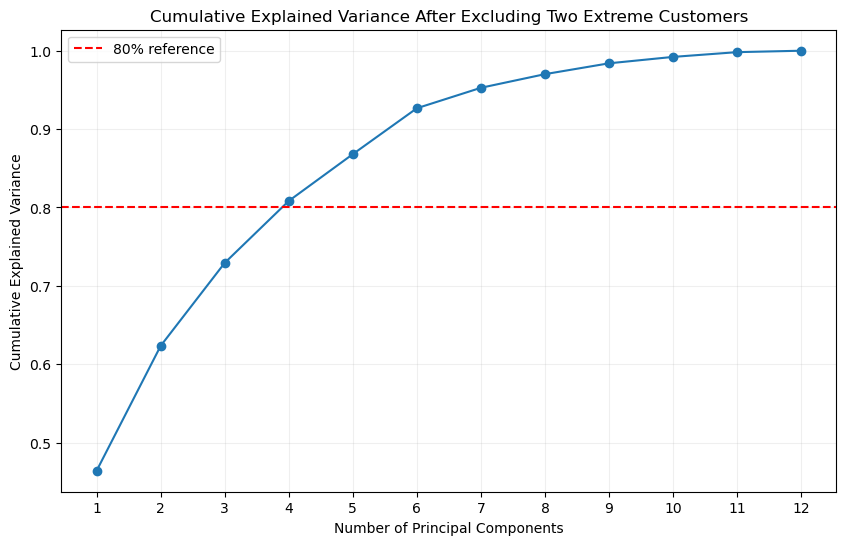

In [19]:
# plot cumulative explained variance to assess components to retain

plt.figure(figsize=(10, 6))
plt.plot(
    variance_no_extreme_outliers["components"],
    variance_no_extreme_outliers["cumulative_variance"],
    marker="o"
)
plt.xticks(variance_no_extreme_outliers["components"])
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance After Excluding Two Extreme Customers")
plt.axhline(0.80, color="r", linestyle="--", label="80% reference")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [20]:
# retain four principal components explaining at least 80% of total variance

pca_no_extreme_outliers = PCA(n_components=4)
pca_data_no_extreme_outliers = pca_no_extreme_outliers.fit_transform(
    scaled_df_no_extreme_outliers
)

pca_df_no_extreme_outliers = pd.DataFrame(
    pca_data_no_extreme_outliers,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=features_no_extreme_outliers.index
)

pca_df_no_extreme_outliers.head()

,PC1,PC2,PC3,PC4
1,0.389193,0.044552,1.084616,-0.739000
2,-0.555333,0.260981,0.320420,-0.054420
3,-0.173900,0.910203,0.726460,-0.808338
4,-1.193710,0.463709,-0.627479,1.787877
5,0.675878,-0.469346,-0.635891,-0.393484


In [21]:
# compare KMeans solutions with 2–10 clusters after excluding the two extreme customers

inertias_no_extreme_outliers = []
silhouettes_no_extreme_outliers = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(pca_data_no_extreme_outliers)

    inertias_no_extreme_outliers.append(model.inertia_)
    silhouettes_no_extreme_outliers.append(
        silhouette_score(pca_data_no_extreme_outliers, labels)
    )

results_no_extreme_outliers = pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias_no_extreme_outliers,
    "silhouette_score": silhouettes_no_extreme_outliers
})

results_no_extreme_outliers

,k,inertia,silhouette_score
0,2,28992.261044,0.926237
1,3,23115.894377,0.632307
2,4,18862.887307,0.611049
3,5,15680.204141,0.454268
4,6,12811.374263,0.453975
5,7,10991.758532,0.467292
6,8,9556.812058,0.466932
7,9,8405.678229,0.463103
8,10,7400.287627,0.463585


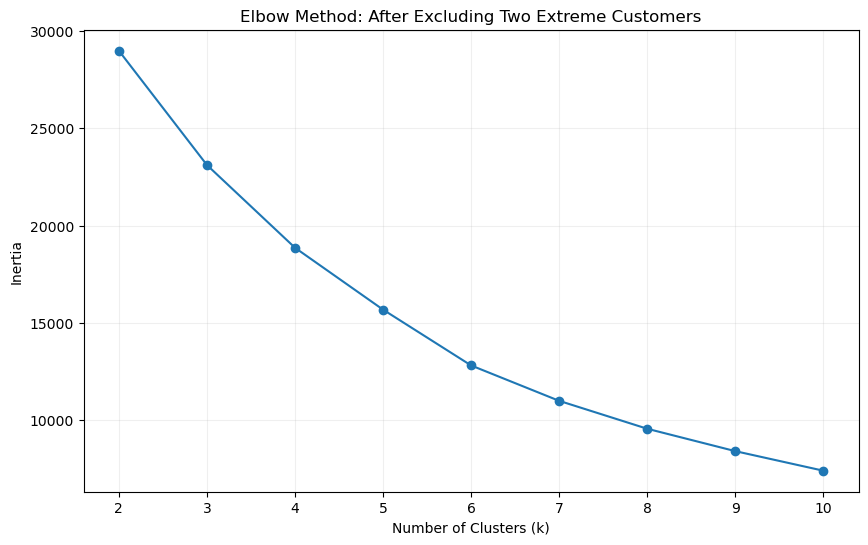

In [22]:
# plot inertia across cluster counts after excluding the two extreme customers

plt.figure(figsize=(10, 6))
plt.plot(
    results_no_extreme_outliers["k"],
    results_no_extreme_outliers["inertia"],
    marker="o"
)
plt.xticks(results_no_extreme_outliers["k"])
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method: After Excluding Two Extreme Customers")
plt.grid(alpha=0.2)
plt.show()

In [23]:
# preserve candidate models and profiles for comparison across 2–6 clusters

candidates_no_extreme_outliers = {}

for k in range(2, 7):
    candidate_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    candidate_review = customer_features_no_extreme_outliers.copy()
    candidate_review["cluster"] = candidate_model.fit_predict(
        pca_data_no_extreme_outliers
    )

    candidate_sizes = (
        candidate_review.groupby("cluster")
        .size()
        .rename("customers")
        .to_frame()
    )

    candidate_sizes["percent"] = (
        candidate_sizes["customers"] / len(candidate_review) * 100
    ).round(2)

    candidate_profile = candidate_sizes.join(
        candidate_review.groupby("cluster")[
            features_no_extreme_outliers.columns
        ].median()
    )

    candidates_no_extreme_outliers[k] = {
        "model": candidate_model,
        "customers": candidate_review,
        "profile": candidate_profile
    }

candidate_sizes_comparison = pd.concat(
    {
        k: candidate["profile"][["customers", "percent"]]
        for k, candidate in candidates_no_extreme_outliers.items()
    },
    names=["k", "cluster"]
)

candidate_sizes_comparison

customers  percent
k cluster                    
2 0             4310    99.49
  1               22     0.51
3 0             3939    90.93
  1              376     8.68
  2               17     0.39
4 0             3900    90.03
  1               19     0.44
  2              408     9.42
  3                5     0.12
5 0              310     7.16
  1               19     0.44
  2             1105    25.51
  3                5     0.12
  4             2893    66.78
6 0             1105    25.51
  1               16     0.37
  2             2894    66.81
  3                5     0.12
  4                2     0.05
  5              310     7.16

In [24]:
# inspect customer profiles for the five-cluster candidate
candidates_no_extreme_outliers[5]["profile"]

,customers,percent,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
cluster,,,,,,,,,,,,,,
0,310,7.16,11.0,13.0,294.0,176.0,2913.0,4902.065,413.71355,4.0,11.0,9.0,36.0,109.70
1,19,0.44,9.0,31.0,337.0,124.0,40207.0,58825.830,2380.48430,4.0,16.0,7.0,953.0,2874.31
2,1105,25.51,240.0,1.0,17.0,17.0,149.0,302.700,226.78000,0.0,0.0,0.0,0.0,0.00
3,5,0.12,2.0,124.0,4580.0,1322.0,25511.0,40967.720,330.38480,35.0,112.0,72.0,474.0,1348.56
4,2893,66.78,33.0,3.0,50.0,43.0,479.0,795.120,295.93000,0.0,0.0,0.0,0.0,0.00


In [25]:
# fit two clusters and compare their sizes and original feature medians

kmeans_no_extreme_outliers = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_no_extreme_outliers = kmeans_no_extreme_outliers.fit_predict(
    pca_data_no_extreme_outliers
)

review_no_extreme_outliers = customer_features_no_extreme_outliers.copy()
review_no_extreme_outliers["cluster"] = labels_no_extreme_outliers

sizes_no_extreme_outliers = (
    review_no_extreme_outliers["cluster"]
    .value_counts()
    .sort_index()
    .rename("customers")
    .to_frame()
)

sizes_no_extreme_outliers["percent"] = (
    sizes_no_extreme_outliers["customers"]
    / len(review_no_extreme_outliers) * 100
).round(2)

cluster_profile_no_extreme_outliers = sizes_no_extreme_outliers.join(
    review_no_extreme_outliers.groupby("cluster")[
        features_no_extreme_outliers.columns
    ].median()
)

cluster_profile_no_extreme_outliers

,customers,percent,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
cluster,,,,,,,,,,,,,,
0,4310,99.49,52.0,2.0,41.0,35.0,376.0,661.800,289.47400,0.0,0.0,0.0,0.0,0.000
1,22,0.51,3.5,52.0,838.0,448.0,34632.0,58428.155,1544.78145,7.5,19.0,16.0,906.0,2096.655


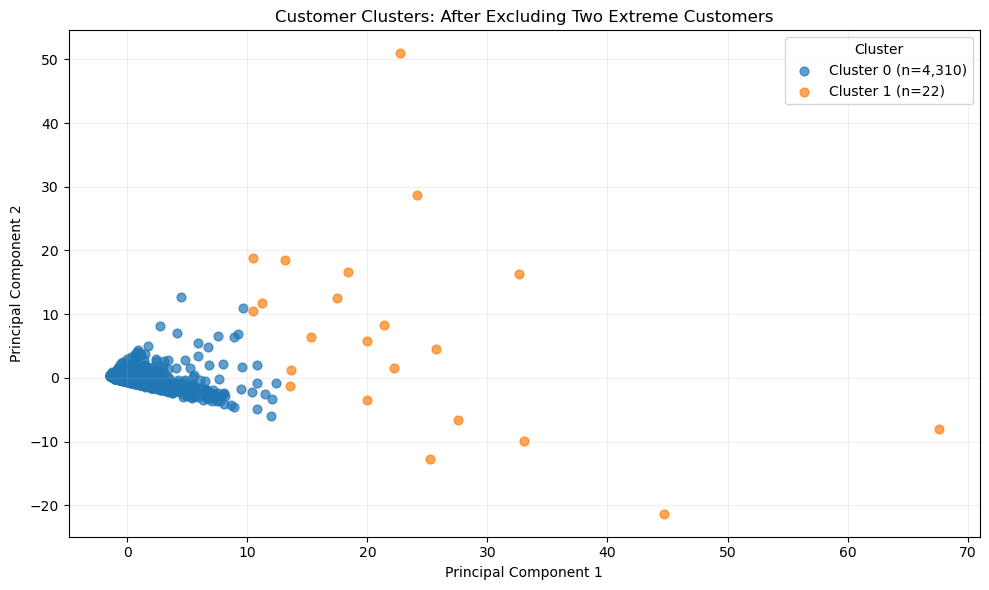

In [26]:
# visualize the two KMeans clusters using the first two principal components

plt.figure(figsize=(10, 6))

for cluster in sorted(np.unique(labels_no_extreme_outliers)):
    mask = labels_no_extreme_outliers == cluster
    plt.scatter(
        pca_data_no_extreme_outliers[mask, 0],
        pca_data_no_extreme_outliers[mask, 1],
        label=f"Cluster {cluster} (n={mask.sum():,})",
        alpha=0.7,
        s=40
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters: After Excluding Two Extreme Customers")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

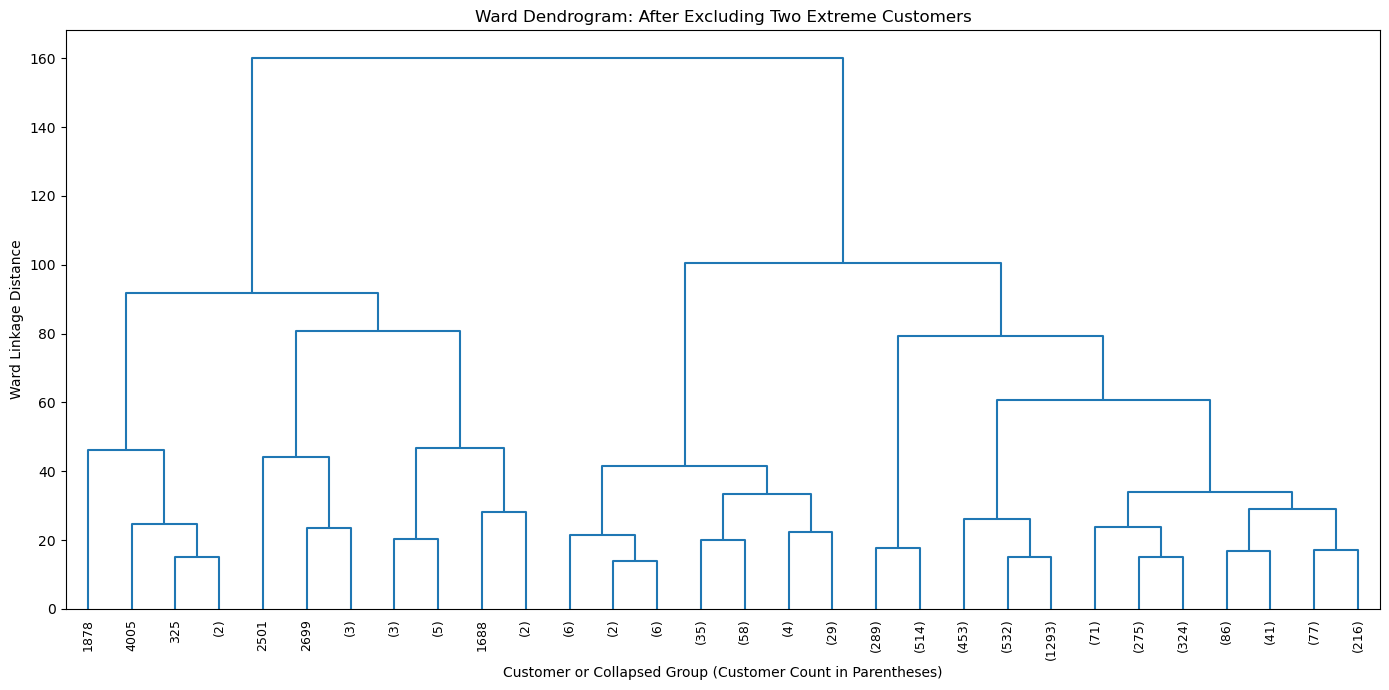

In [27]:
ward_linkage_no_extreme_outliers = linkage(
    pca_data_no_extreme_outliers,
    method="ward"
)

plt.figure(figsize=(14, 7))
dendrogram(
    ward_linkage_no_extreme_outliers,
    truncate_mode="lastp",
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0
)
plt.title("Ward Dendrogram: After Excluding Two Extreme Customers")
plt.xlabel("Customer or Collapsed Group (Customer Count in Parentheses)")
plt.ylabel("Ward Linkage Distance")
plt.tight_layout()
plt.show()

In [28]:
# list the displayed dendrogram branches and their actual customer counts

ward_tree = dendrogram(
    ward_linkage_no_extreme_outliers,
    truncate_mode="lastp",
    p=30,
    no_plot=True
)

# A linkage matrix has one fewer row than the number of customers
n_ward_customers = ward_linkage_no_extreme_outliers.shape[0] + 1

ward_displayed_groups = pd.DataFrame({
    "position_from_left": range(1, len(ward_tree["leaves"]) + 1),
    "node_id": ward_tree["leaves"],
    "displayed_label": ward_tree["ivl"],
    "customers": [
        1 if node < n_ward_customers
        else int(
            ward_linkage_no_extreme_outliers[node - n_ward_customers, 3]
        )
        for node in ward_tree["leaves"]
    ]
})

ward_displayed_groups

,position_from_left,node_id,displayed_label,customers
0,1,1878,1878,1
1,2,4005,4005,1
2,3,325,325,1
3,4,8615,(2),2
4,5,2501,2501,1
5,6,2699,2699,1
6,7,8618,(3),3
7,8,8629,(3),3
8,9,8633,(5),5
9,10,1688,1688,1


In [29]:
# compare the smaller clusters from two-cluster Ward and KMeans solutions

from scipy.cluster.hierarchy import cut_tree

ward_review = customer_features_no_extreme_outliers.copy()
ward_review["cluster"] = cut_tree(
    ward_linkage_no_extreme_outliers,
    n_clusters=2
).ravel()

ward_small_label = ward_review["cluster"].value_counts().idxmin()
ward_small_group = ward_review.loc[
    ward_review["cluster"] == ward_small_label
].copy()

kmeans_review = candidates_no_extreme_outliers[2]["customers"]
kmeans_small_label = kmeans_review["cluster"].value_counts().idxmin()
kmeans_small_group = kmeans_review.loc[
    kmeans_review["cluster"] == kmeans_small_label
].copy()

ward_ids = set(ward_small_group["customer_id"])
kmeans_ids = set(kmeans_small_group["customer_id"])

membership_comparison = pd.DataFrame({
    "comparison": [
        "Customers in smaller Ward cluster",
        "Customers in smaller KMeans cluster",
        "Customers shared by both",
        "Customers only in Ward",
        "Customers only in KMeans"
    ],
    "customers": [
        len(ward_ids),
        len(kmeans_ids),
        len(ward_ids & kmeans_ids),
        len(ward_ids - kmeans_ids),
        len(kmeans_ids - ward_ids)
    ]
})

membership_comparison

,comparison,customers
0,Customers in smaller Ward cluster,21
1,Customers in smaller KMeans cluster,22
2,Customers shared by both,19
3,Customers only in Ward,2
4,Customers only in KMeans,3


In [30]:
# Inspect customers assigned to the smaller cluster by only one method
different_ids = ward_ids.symmetric_difference(kmeans_ids)

membership_differences = customer_features_no_extreme_outliers.loc[
    customer_features_no_extreme_outliers["customer_id"].isin(different_ids),
    ["customer_id"] + list(features_no_extreme_outliers.columns)
].copy()

membership_differences["in_small_ward_cluster"] = (
    membership_differences["customer_id"].isin(ward_ids)
)
membership_differences["in_small_kmeans_cluster"] = (
    membership_differences["customer_id"].isin(kmeans_ids)
)

membership_differences.sort_values("purchase_value", ascending=False)

,customer_id,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value,in_small_ward_cluster,in_small_kmeans_cluster
3174,16684,5,28,277,119,50255,66653.56,2380.4843,3,4,4,865,761.48,True,False
4089,17949,2,44,69,28,30450,58030.48,1318.8745,5,7,7,2878,4814.74,False,True
2517,15769,8,26,130,26,29672,56252.72,2163.5662,3,17,16,2012,4429.00,False,True
1069,13798,2,57,349,113,23948,37153.85,651.8219,6,90,35,434,802.43,False,True
1662,14607,16,12,78,37,10734,15021.50,1251.7917,3,28,27,3768,5228.40,True,False


### Moving to log-transformed features

After excluding customers 12346 and 16446, the unlogged two-cluster KMeans solution still placed 4,310 customers in one group and 22 in the other. Its high silhouette score reflected a strong separation of a small group with unusually large activity measures, but offered limited detail about the broader customer population.

The Ward comparison identified a similar, though not identical, small group. Reviewing the customers assigned differently did not establish a common reason for further exclusions, so all 4,332 remaining customers were retained.

To reduce skew and the influence of large counts and amounts, the next analysis applies `log1p` to the eleven features other than recency. Recency remains unlogged, and all twelve features are then standardized. PCA and KMeans are refitted on the transformed data, with candidate solutions assessed using cluster sizes, silhouette scores, and customer profiles in their original units.

In [31]:
# reduce skew in purchase and cancellation features while retaining all remaining customers

features_log = features_no_extreme_outliers.copy()

# keep recency in days and transform transaction counts and amounts

log_columns = features_log.columns.drop("recency_days")

if (features_log[log_columns] < 0).any().any():
    raise ValueError("Check negative values before applying log1p.")

features_log[log_columns] = np.log1p(features_log[log_columns])

features_log.head()

,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
1,3,2.079442,5.209486,4.644391,7.807510,8.368925,6.424406,0.000000,0.000000,0.000000,0.000000,0.000000
2,76,1.609438,3.332205,3.091042,7.754910,7.271175,5.886965,0.000000,0.000000,0.000000,0.000000,0.000000
3,19,0.693147,4.290459,4.290459,6.447306,7.285198,7.285198,0.000000,0.000000,0.000000,0.000000,0.000000
4,311,0.693147,2.833213,2.833213,5.283204,5.688330,5.688330,0.000000,0.000000,0.000000,0.000000,0.000000
5,37,2.079442,4.356709,4.060443,6.267201,7.234711,5.293118,0.693147,2.079442,2.079442,4.158883,4.798514


In [32]:
# standardize the log-transformed features and unchanged recency before PCA

scaler_log = StandardScaler()

scaled_log_df = pd.DataFrame(
    scaler_log.fit_transform(features_log),
    columns=features_log.columns,
    index=features_log.index
)

scaled_log_df.head()

,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
1,-0.900909,1.081869,1.179943,0.966559,1.341162,1.432978,1.069127,-0.632681,-0.605794,-0.610555,-0.592206,-0.658735
2,-0.171744,0.392492,-0.321393,-0.405139,1.302419,0.554753,0.336278,-0.632681,-0.605794,-0.610555,-0.592206,-0.658735
3,-0.741092,-0.951476,0.444961,0.654016,0.339295,0.565972,2.242893,-0.632681,-0.605794,-0.610555,-0.592206,-0.658735
4,2.175565,-0.951476,-0.720456,-0.632817,-0.518132,-0.711560,0.065422,-0.632681,-0.605794,-0.610555,-0.592206,-0.658735
5,-0.561298,1.081869,0.497943,0.450898,0.206637,0.525581,-0.473484,0.593763,1.882295,1.984929,2.198680,1.869125


In [33]:
# fit PCA on the standardized log-transformed features and examine cumulative explained variance

pca_log_full = PCA()
pca_log_full.fit(scaled_log_df)

variance_log = pd.DataFrame({
    "components": np.arange(1, len(features_log.columns) + 1),
    "cumulative_variance": pca_log_full.explained_variance_ratio_.cumsum()
})

variance_log

,components,cumulative_variance
0,1,0.598267
1,2,0.787568
2,3,0.871568
3,4,0.925761
4,5,0.964588
5,6,0.978837
6,7,0.987557
7,8,0.995176
8,9,0.998735
9,10,0.999445


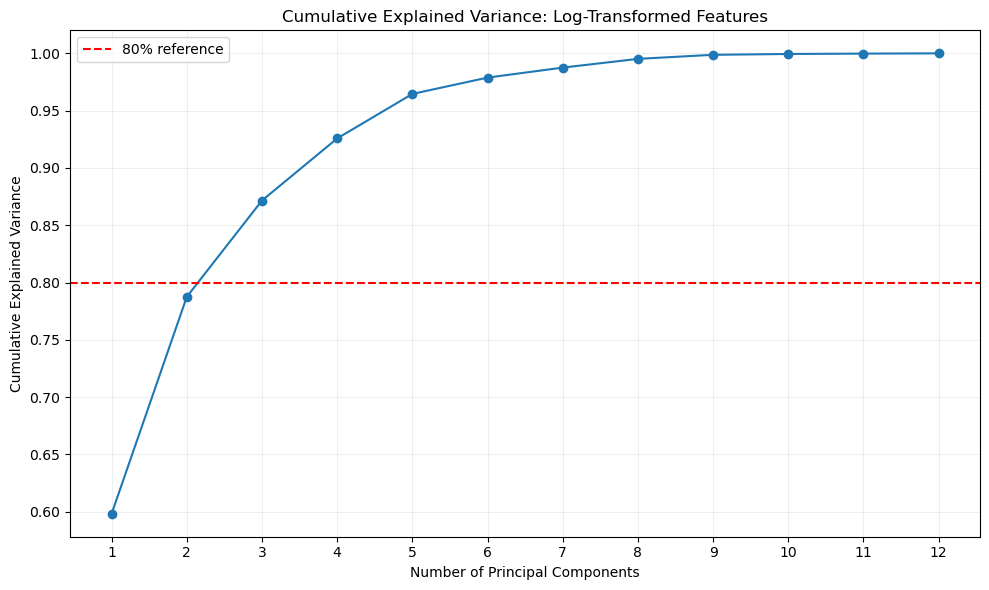

In [34]:
# plot cumulative explained variance for the log-transformed analysis

plt.figure(figsize=(10, 6))
plt.plot(
    variance_log["components"],
    variance_log["cumulative_variance"],
    marker="o"
)
plt.xticks(variance_log["components"])
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance: Log-Transformed Features")
plt.axhline(0.80, color="r", linestyle="--", label="80% reference")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [35]:
# retain three principal components explaining 87.16% of variance in the log analysis

pca_log = PCA(n_components=3)
pca_log_data = pca_log.fit_transform(scaled_log_df)

pca_log_df = pd.DataFrame(
    pca_log_data,
    columns=["PC1", "PC2", "PC3"],
    index=features_log.index
)

pca_log_df.head()

,PC1,PC2,PC3
1,1.163973,3.081022,0.102359
2,-0.391074,1.413006,0.352329
3,-0.138240,2.186459,1.556437
4,-2.377303,-0.471439,1.422424
5,3.508955,-1.990129,-0.806047


In [36]:
# compare KMeans solutions with 2–10 clusters using the log-transformed PCA data

inertias_log = []
silhouettes_log = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(pca_log_data)

    inertias_log.append(model.inertia_)
    silhouettes_log.append(silhouette_score(pca_log_data, labels))

results_log = pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias_log,
    "silhouette_score": silhouettes_log
})

results_log

,k,inertia,silhouette_score
0,2,23863.886574,0.468569
1,3,16948.193385,0.353154
2,4,13475.032823,0.357506
3,5,11676.695010,0.305645
4,6,9955.771000,0.315345
5,7,8963.958491,0.311599
6,8,8168.709655,0.307551
7,9,7527.642484,0.296693
8,10,7011.896572,0.299928


In [37]:
# fit and preserve log-based KMeans candidates with 2, 3, and 4 clusters

candidates_log = {}

for k in [2, 3, 4]:
    candidate_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    candidate_labels = candidate_model.fit_predict(pca_log_data)

    candidate_sizes = (
        pd.Series(candidate_labels, name="cluster")
        .value_counts()
        .sort_index()
        .rename("customers")
        .to_frame()
    )

    candidate_sizes["percent"] = (
        candidate_sizes["customers"] / len(candidate_labels) * 100
    ).round(2)

    candidates_log[k] = {
        "model": candidate_model,
        "labels": candidate_labels,
        "sizes": candidate_sizes
    }

sizes_comparison_log = pd.concat(
    {
        k: candidate["sizes"]
        for k, candidate in candidates_log.items()
    },
    names=["k", "cluster"]
)

sizes_comparison_log

customers  percent
k cluster                    
2 0             3145    72.60
  1             1187    27.40
3 0             1660    38.32
  1             1045    24.12
  2             1627    37.56
4 0             1416    32.69
  1              436    10.06
  2             1521    35.11
  3              959    22.14

In [38]:
# compare original-unit customer profiles across the log-based candidates

for k, candidate in candidates_log.items():
    candidate_review = customer_features_no_extreme_outliers.copy()
    candidate_review["cluster"] = candidate["labels"]

    candidate_profile = candidate["sizes"].join(
        candidate_review.groupby("cluster")[features_log.columns].median()
    )

    candidate["customers"] = candidate_review
    candidate["profile"] = candidate_profile

profiles_comparison_log = pd.concat(
    {
        k: candidate["profile"]
        for k, candidate in candidates_log.items()
    },
    names=["k", "cluster"]
)

profiles_comparison_log

customers  percent  recency_days  purchase_frequency  \
k cluster                                                         
2 0             3145    72.60          67.0                 2.0   
  1             1187    27.40          23.0                 6.0   
3 0             1660    38.32         142.5                 1.0   
  1             1045    24.12          23.0                 6.0   
  2             1627    37.56          36.0                 3.0   
4 0             1416    32.69          37.0                 3.0   
  1              436    10.06          13.0                11.0   
  2             1521    35.11         142.0                 1.0   
  3              959    22.14          36.0                 4.0   

           purchase_line_count  distinct_products  purchase_quantity  \
k cluster                                                              
2 0                       28.0               26.0              252.0   
  1                      113.0               83.0             1269.0   
3 0                       14.0               13.0              130.0   
  1                      117.0               87.0             1361.0   
  2                       62.0               52.0              561.0   
4 0                       62.0               53.0              546.5   
  1                      224.0              133.0             2645.0   
  2                       13.0               13.0              125.0   
  3                       66.0               52.0              671.0   

           purchase_value  average_order_value  cancellation_frequency  \
k cluster                                                                
2 0               429.840             243.8400                     0.0   
  1              2188.050             367.3638                     2.0   
3 0               243.320             180.7700                     0.0   
  1              2332.150             370.6800                     2.0   
  2               942.260             336.5167                     0.0   
4 0               912.595             339.6225                     0.0   
  1              4611.360             424.6041                     4.0   
  2               226.780             174.9000                     0.0   
  3              1186.350             326.0027                     1.0   

           cancellation_line_count  distinct_cancelled_products  \
k cluster                                                         
2 0                            0.0                          0.0   
  1                            3.0                          3.0   
3 0                            0.0                          0.0   
  1                            4.0                          4.0   
  2                            0.0                          0.0   
4 0                            0.0                          0.0   
  1                            8.0                          7.0   
  2                            0.0                          0.0   
  3                            2.0                          2.0   

           cancelled_quantity  cancellation_value  
k cluster                                          
2 0                       0.0               0.000  
  1                      12.0              40.200  
3 0                       0.0               0.000  
  1                      16.0              46.800  
  2                       0.0               0.000  
4 0                       0.0               0.000  
  1                      35.0             103.065  
  2                       0.0               0.000  
  3                       6.0              20.750

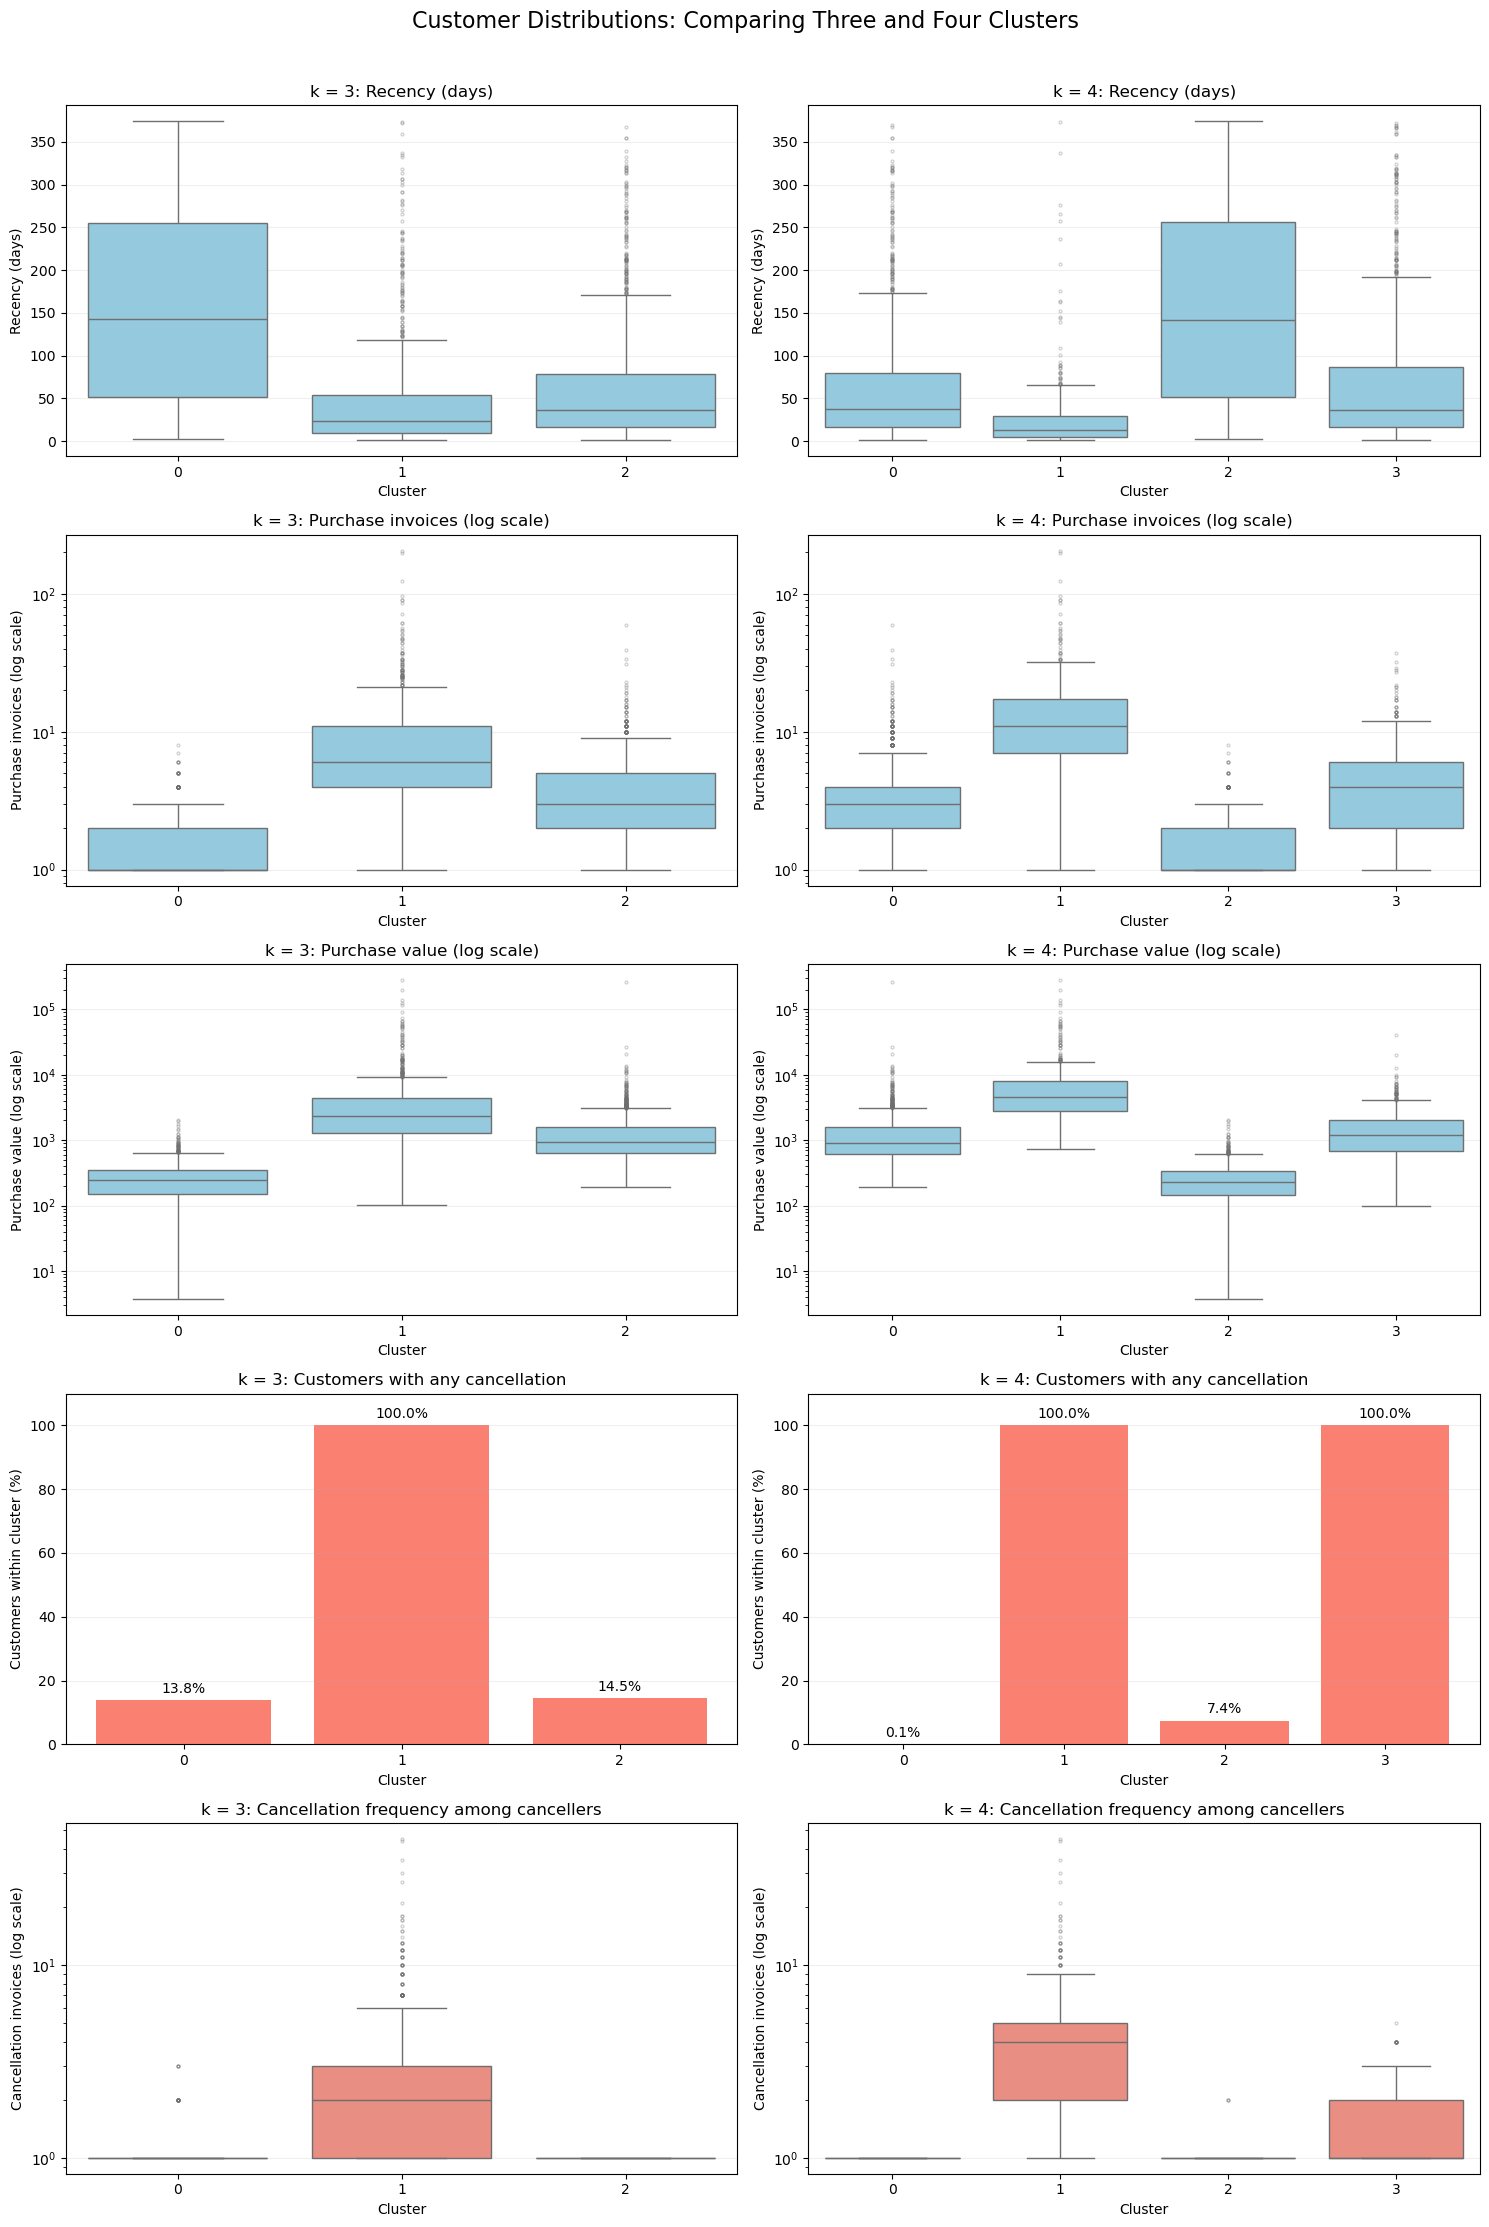

In [39]:
# compare purchase distributions and cancellation behavior for k = 3 and k = 4

fig, axes = plt.subplots(5, 2, figsize=(15, 22))

purchase_metrics = [
    ("recency_days", "Recency (days)", False),
    ("purchase_frequency", "Purchase invoices", True),
    ("purchase_value", "Purchase value", True)
]

for col, k in enumerate([3, 4]):
    review = candidates_log[k]["customers"]
    cluster_order = sorted(review["cluster"].unique())

    # Compare purchasing behavior in original units
    for row, (feature, label, use_log) in enumerate(purchase_metrics):
        ax = axes[row, col]

        sns.boxplot(
            data=review,
            x="cluster",
            y=feature,
            order=cluster_order,
            color="skyblue",
            flierprops={"markersize": 2, "alpha": 0.3},
            ax=ax
        )

        if use_log:
            ax.set_yscale("log")
            label += " (log scale)"

        ax.set_title(f"k = {k}: {label}")
        ax.set_xlabel("Cluster")
        ax.set_ylabel(label)
        ax.grid(axis="y", alpha=0.2)

    # Measure how common cancellation activity is within each cluster
    cancellation_percent = (
        review.assign(
            has_cancellation=review["cancellation_frequency"] > 0
        )
        .groupby("cluster")["has_cancellation"]
        .mean()
        .reindex(cluster_order)
        .mul(100)
    )

    ax = axes[3, col]
    bars = ax.bar(
        [str(cluster) for cluster in cluster_order],
        cancellation_percent.values,
        color="salmon"
    )
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_ylim(0, 110)
    ax.set_yticks(range(0, 101, 20))
    ax.set_title(f"k = {k}: Customers with any cancellation")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Customers within cluster (%)")
    ax.grid(axis="y", alpha=0.2)

    # Examine cancellation frequency only among customers with cancellations
    cancellation_customers = review.loc[
        review["cancellation_frequency"] > 0
    ]

    ax = axes[4, col]
    sns.boxplot(
        data=cancellation_customers,
        x="cluster",
        y="cancellation_frequency",
        order=cluster_order,
        color="salmon",
        flierprops={"markersize": 2, "alpha": 0.3},
        ax=ax
    )
    ax.set_yscale("log")
    ax.set_title(f"k = {k}: Cancellation frequency among cancellers")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Cancellation invoices (log scale)")
    ax.grid(axis="y", alpha=0.2)

fig.suptitle(
    "Customer Distributions: Comparing Three and Four Clusters",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.show()

In [40]:
# select the four-cluster log-based model and preserve original customer values

selected_k = 4

final_kmeans_log = candidates_log[selected_k]["model"]
final_labels_log = candidates_log[selected_k]["labels"].copy()

customer_segments_log = customer_features_no_extreme_outliers.copy()
customer_segments_log["cluster"] = final_labels_log

final_cluster_profile_log = candidates_log[selected_k]["profile"].copy()

final_cluster_profile_log

,customers,percent,recency_days,purchase_frequency,purchase_line_count,distinct_products,purchase_quantity,purchase_value,average_order_value,cancellation_frequency,cancellation_line_count,distinct_cancelled_products,cancelled_quantity,cancellation_value
cluster,,,,,,,,,,,,,,
0,1416,32.69,37.0,3.0,62.0,53.0,546.5,912.595,339.6225,0.0,0.0,0.0,0.0,0.000
1,436,10.06,13.0,11.0,224.0,133.0,2645.0,4611.360,424.6041,4.0,8.0,7.0,35.0,103.065
2,1521,35.11,142.0,1.0,13.0,13.0,125.0,226.780,174.9000,0.0,0.0,0.0,0.0,0.000
3,959,22.14,36.0,4.0,66.0,52.0,671.0,1186.350,326.0027,1.0,2.0,2.0,6.0,20.750


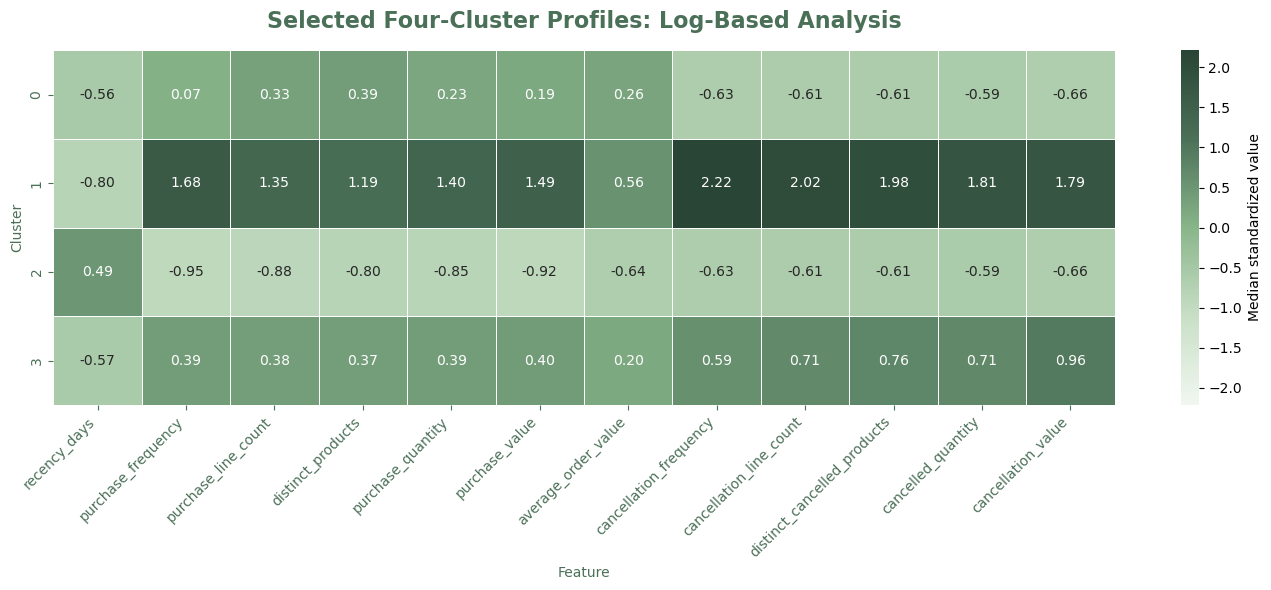

In [41]:
# Standardized feature medians for the selected four-cluster log model
scaled_review_log = scaled_log_df.copy()
scaled_review_log["cluster"] = final_labels_log

heatmap_log = (
    scaled_review_log
    .groupby("cluster")[features_log.columns]
    .median()
)

color_limit = np.abs(heatmap_log.to_numpy()).max()

fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")

sns.heatmap(
    heatmap_log,
    cmap=dashboard_greens,
    vmin=-color_limit,
    vmax=color_limit,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Median standardized value"},
    ax=ax
)

ax.set_title(
    "Selected Four-Cluster Profiles: Log-Based Analysis",
    color="#4B7058",
    fontsize=16,
    fontweight="bold",
    pad=16
)
ax.set_xlabel("Feature", color="#4B7058")
ax.set_ylabel("Cluster", color="#4B7058")
ax.tick_params(axis="both", colors="#4B7058")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [42]:
# Export the selected model's median standardized feature values
heatmap_export = (
    heatmap_log
    .rename_axis("cluster")
    .reset_index()
    .melt(
        id_vars="cluster",
        var_name="feature",
        value_name="median_standardized_value"
    )
)

export_dir = Path("Exports")
export_dir.mkdir(parents=True, exist_ok=True)

heatmap_export.to_csv(
    export_dir / "log_segment_profiles_heatmap_values.csv",
    index=False
)

### Selection and interpretation of the four-cluster solution

The four-cluster solution was selected because it provides interpretable differences in purchasing and cancellation behavior among the 4,332 retained customers.

Although two clusters achieved the highest tested silhouette score, four clusters provide additional behavioral detail. The silhouette scores for three and four clusters were similar (0.353 and 0.358), so the choice between them rests primarily on the usefulness of their customer profiles.

| Cluster | Customers | Proportion | Behavioral description |
|---|---:|---:|---|
| 0 | 1,416 | 32.69% | Recent, moderate purchasers with very little cancellation activity |
| 1 | 436 | 10.06% | Recent, high-activity purchasers with frequent cancellations |
| 2 | 1,521 | 35.11% | Less recent, infrequent purchasers with low spending |
| 3 | 959 | 22.14% | Recent, moderate purchasers with cancellation activity |

Clusters 0 and 3 have overlapping purchasing distributions, but differ sharply in cancellation participation: approximately 0.1% of cluster 0 and 100% of cluster 3 have recorded cancellations. Cluster 1 shows substantially greater purchasing activity, while cluster 2 has older and less frequent purchases.

These descriptions summarize group tendencies, not every customer. Cancellation counts do not establish cancellation rates, and the heatmap shows median profiles rather than complete separation. The selected solution remains exploratory. The following sections assess its sensitivity to random initialization and the treatment of repeated source records.

In [43]:
# check whether the selected four-cluster solution is consistent across random seeds

from sklearn.metrics import adjusted_rand_score

stability_results = []

for seed in [4, 8, 15, 16, 23, 42]:
    stability_model = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )

    stability_labels = stability_model.fit_predict(pca_log_data)

    stability_results.append({
        "seed": seed,
        "inertia": stability_model.inertia_,
        "ARI_vs_selected": adjusted_rand_score(
            final_labels_log,
            stability_labels
        )
    })

stability_log = pd.DataFrame(stability_results)
stability_log.style.format({
    "inertia": "{:.6f}",
    "ARI_vs_selected": "{:.12f}"
})

,seed,inertia,ARI_vs_selected
0,4,13475.032823,1.000000000000
1,8,13475.032823,1.000000000000
2,15,13475.020105,1.000000000000
3,16,13475.032823,1.000000000000
4,23,13475.032823,1.000000000000
5,42,13475.032823,1.000000000000


### Stability across initializations

The selected four-cluster model was compared with models fitted using random seeds 4, 8, 15, 16, 23, and 42. Each fit used the same log-transformed PCA data and ten initializations (`n_init=10`).

All comparisons returned an adjusted Rand index of 1.000000000000 against the selected model, indicating matching customer groupings to the displayed precision. Inertia values were nearly identical.

These results support stability with respect to initialization under the tested settings. They do not establish stability across different customer samples or time periods, or prove that four clusters is optimal.

In [44]:
# attach descriptive names to the selected four-cluster customer assignments

segment_names = {
    0: "Recent moderate purchasers and minimal cancellations",
    1: "Recent high-activity purchasers and frequent cancellations",
    2: "Less recent infrequent purchasers",
    3: "Recent moderate purchasers and some cancellation activity"
}

customer_segments_log["segment"] = (
    customer_segments_log["cluster"].map(segment_names)
)

customer_segments_log[
    ["customer_id", "cluster", "segment"]
].head()

,customer_id,cluster,segment
1,12347,0,Recent moderate purchasers and minimal cancell...
2,12348,0,Recent moderate purchasers and minimal cancell...
3,12349,0,Recent moderate purchasers and minimal cancell...
4,12350,2,Less recent infrequent purchasers
5,12352,3,Recent moderate purchasers and some cancellati...


In [45]:
# Summarize the size and purchasing contribution of each selected segment
segment_summary = (
    customer_segments_log
    .groupby(["cluster", "segment"])
    .agg(
        customers=("customer_id", "size"),
        purchase_invoices=("purchase_frequency", "sum"),
        purchase_value=("purchase_value", "sum"),
        median_recency_days=("recency_days", "median"),
        customers_with_cancellations=(
            "cancellation_frequency",
            lambda values: (values > 0).sum()
        )
    )
)

segment_summary["customer_percent"] = (
    segment_summary["customers"]
    / segment_summary["customers"].sum() * 100
)

segment_summary["purchase_value_percent"] = (
    segment_summary["purchase_value"]
    / segment_summary["purchase_value"].sum() * 100
)

segment_summary["customers_with_cancellations_percent"] = (
    segment_summary["customers_with_cancellations"]
    / segment_summary["customers"] * 100
)

segment_summary.round(2)

,,customers,purchase_invoices,purchase_value,median_recency_days,customers_with_cancellations,customer_percent,purchase_value_percent,customers_with_cancellations_percent
cluster,segment,,,,,,,,
0,Recent moderate purchasers and minimal cancellations,1416,5225,2225068.16,37.0,2,32.69,26.13,0.14
1,Recent high-activity purchasers and frequent cancellations,436,6712,4325666.88,13.0,436,10.06,50.81,100.00
2,Less recent infrequent purchasers,1521,2078,402361.16,142.0,113,35.11,4.73,7.43
3,Recent moderate purchasers and some cancellation activity,959,4384,1561009.35,36.0,959,22.14,18.33,100.00


In [46]:
# compare aggregate cancellation and purchase values within each segment

segment_cancellation_summary = (
    customer_segments_log
    .groupby(["cluster", "segment"])
    .agg(
        customers=("customer_id", "size"),
        purchase_value=("purchase_value", "sum"),
        cancellation_value=("cancellation_value", "sum")
    )
)

segment_cancellation_summary["cancellation_to_purchase_value_percent"] = (
    segment_cancellation_summary["cancellation_value"]
    / segment_cancellation_summary["purchase_value"] * 100
)

segment_cancellation_summary.round(2)

,,customers,purchase_value,cancellation_value,cancellation_to_purchase_value_percent
cluster,segment,,,,
0,Recent moderate purchasers and minimal cancellations,1416,2225068.16,2.90,0.00
1,Recent high-activity purchasers and frequent cancellations,436,4325666.88,192729.86,4.46
2,Less recent infrequent purchasers,1521,402361.16,1792.36,0.45
3,Recent moderate purchasers and some cancellation activity,959,1561009.35,43901.68,2.81


## Sensitivity to repeated source records

The primary analysis retains all recorded source occurrences.
This comparison keeps one occurrence per exact group across the
eight loaded source fields.

Both analyses exclude customers 12346 and 16446 and use the same
12 behavioral features and modeling procedure. The comparison
examines whether this alternative policy materially changes
customer groupings or segment interpretation.

Repeated source records are not assumed to be errors.

In [47]:
# Load the alternative features without changing the primary dataset
customer_features_one_per_group = pd.read_csv(
    "customer_features_one_per_group.csv",
    dtype={"customer_id": "string"}
)

# Both inputs must have populated, unique customer IDs
for name, data in {
    "Primary": customer_features,
    "One per group": customer_features_one_per_group
}.items():
    if data["customer_id"].isna().any():
        raise ValueError(f"{name}: missing customer IDs.")

    if data["customer_id"].duplicated().any():
        raise ValueError(f"{name}: duplicate customer IDs.")

# Check that the alternative contains the same full customer cohort
if set(customer_features_one_per_group["customer_id"]) != set(
    customer_features["customer_id"]
):
    raise ValueError("The two datasets contain different customers.")

# Confirm the same modeling features are available
model_columns = features_no_extreme_outliers.columns.tolist()

missing_columns = set(model_columns) - set(
    customer_features_one_per_group.columns
)

if missing_columns:
    raise ValueError(f"Missing modeling features: {sorted(missing_columns)}")

# Apply the same two exclusions used in the primary analysis
alternative_retained = customer_features_one_per_group.loc[
    ~customer_features_one_per_group["customer_id"].isin(
        ["12346", "16446"]
    )
].copy()

# Align the alternative rows to the primary dataset by customer ID
primary_customer_order = (
    customer_features_no_extreme_outliers["customer_id"].tolist()
)

if set(alternative_retained["customer_id"]) != set(primary_customer_order):
    raise ValueError("The retained customer cohorts do not match.")

alternative_retained = (
    alternative_retained
    .set_index("customer_id")
    .loc[primary_customer_order]
    .reset_index()
)

# Keep original-unit model features for the upcoming transformation
features_one_per_group = alternative_retained[model_columns].copy()

if features_one_per_group.isna().any().any():
    raise ValueError("The alternative model features contain missing values.")

if not np.isfinite(features_one_per_group.to_numpy(dtype=float)).all():
    raise ValueError("The alternative model features contain nonfinite values.")

if (features_one_per_group < 0).any().any():
    raise ValueError("Check negative values before applying log1p.")

print(f"Alternative customers loaded: {len(customer_features_one_per_group):,}")
print(f"Retained customers: {len(alternative_retained):,}")
print(f"Model features: {len(model_columns)}")
print(
    "Customer order matches primary:",
    alternative_retained["customer_id"].tolist() == primary_customer_order
)

Alternative customers loaded: 4,334
Retained customers: 4,332
Model features: 12
Customer order matches primary: True


In [48]:
# Apply the same log transformation as the primary analysis
features_log_one_per_group = features_one_per_group.copy()

log_columns_one_per_group = (
    features_log_one_per_group.columns.drop("recency_days")
)

features_log_one_per_group[log_columns_one_per_group] = np.log1p(
    features_log_one_per_group[log_columns_one_per_group]
)

# Refit standardization on the alternative features
scaler_one_per_group = StandardScaler()

scaled_one_per_group = scaler_one_per_group.fit_transform(
    features_log_one_per_group
)

# Retain the same three-component specification
pca_one_per_group = PCA(n_components=3)

pca_data_one_per_group = pca_one_per_group.fit_transform(
    scaled_one_per_group
)

# Fit a separate model using the primary model's settings
kmeans_one_per_group = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_one_per_group = kmeans_one_per_group.fit_predict(
    pca_data_one_per_group
)

print(
    "Variance retained by three PCs:",
    f"{pca_one_per_group.explained_variance_ratio_.sum():.2%}"
)

print("\nAlternative cluster sizes:")
print(
    pd.Series(labels_one_per_group, name="cluster")
    .value_counts()
    .sort_index()
    .rename("customers")
)

Variance retained by three PCs: 87.16%

Alternative cluster sizes:
cluster
0    1407
1     435
2    1530
3     960
Name: customers, dtype: int64


In [49]:
# Compare assignments for the same customers in the same order
duplicate_policy_membership = pd.DataFrame({
    "customer_id": alternative_retained["customer_id"].to_numpy(),
    "primary_cluster": np.asarray(final_labels_log),
    "alternative_cluster": np.asarray(labels_one_per_group)
})

# ARI compares groupings independently of cluster-number labels
duplicate_policy_ari = adjusted_rand_score(
    duplicate_policy_membership["primary_cluster"],
    duplicate_policy_membership["alternative_cluster"]
)

# Show where each primary cluster's customers appear
membership_overlap = pd.crosstab(
    duplicate_policy_membership["primary_cluster"],
    duplicate_policy_membership["alternative_cluster"],
    rownames=["Primary cluster"],
    colnames=["Alternative cluster"],
    margins=True,
    margins_name="Total"
)

print(f"Adjusted Rand index: {duplicate_policy_ari:.6f}")
display(membership_overlap)

Adjusted Rand index: 0.992806


Alternative cluster,0,1,2,3,Total
Primary cluster,,,,,
0,1407,0,9,0,1416
1,0,435,0,1,436
2,0,0,1521,0,1521
3,0,0,0,959,959
Total,1407,435,1530,960,4332


In [50]:
# Attach alternative labels to original-unit alternative features
customer_segments_one_per_group = alternative_retained.copy()
customer_segments_one_per_group["cluster"] = labels_one_per_group

# Summarize each model using its own original-unit feature values
def summarize_duplicate_policy(data):
    summary = (
        data.groupby("cluster")
        .agg(
            customers=("customer_id", "size"),
            median_recency_days=("recency_days", "median"),
            median_purchase_invoices=("purchase_frequency", "median"),
            median_purchase_value=("purchase_value", "median"),
            total_purchase_value=("purchase_value", "sum"),
            customers_with_cancellations=(
                "cancellation_frequency",
                lambda values: (values > 0).sum()
            ),
            total_cancellation_value=("cancellation_value", "sum")
        )
    )

    summary["purchase_value_proportion_pct"] = (
        summary["total_purchase_value"]
        / summary["total_purchase_value"].sum() * 100
    )

    summary["customers_with_cancellations_pct"] = (
        summary["customers_with_cancellations"]
        / summary["customers"] * 100
    )

    summary["cancellation_to_purchase_value_pct"] = (
        summary["total_cancellation_value"]
        / summary["total_purchase_value"] * 100
    )

    return summary


# Direct cluster-number comparison is supported by the overlap table
duplicate_policy_profiles = pd.concat(
    {
        "Primary": summarize_duplicate_policy(customer_segments_log),
        "One per group": summarize_duplicate_policy(
            customer_segments_one_per_group
        )
    },
    names=["policy", "cluster"]
).swaplevel("policy", "cluster").sort_index()

display(duplicate_policy_profiles.round(2))

customers  median_recency_days  \
cluster policy                                          
0       One per group       1407                 37.0   
        Primary             1416                 37.0   
1       One per group        435                 13.0   
        Primary              436                 13.0   
2       One per group       1530                141.0   
        Primary             1521                142.0   
3       One per group        960                 36.0   
        Primary              959                 36.0   

                       median_purchase_invoices  median_purchase_value  \
cluster policy                                                           
0       One per group                       3.0                 916.13   
        Primary                             3.0                 912.60   
1       One per group                      11.0                4623.30   
        Primary                            11.0                4611.36   
2       One per group                       1.0                 226.29   
        Primary                             1.0                 226.78   
3       One per group                       4.0                1173.12   
        Primary                             4.0                1186.35   

                       total_purchase_value  customers_with_cancellations  \
cluster policy                                                              
0       One per group            2212488.41                             2   
        Primary                  2225068.16                             2   
1       One per group            4316776.94                           435   
        Primary                  4325666.88                           436   
2       One per group             403249.06                           113   
        Primary                   402361.16                           113   
3       One per group            1557752.13                           960   
        Primary                  1561009.35                           959   

                       total_cancellation_value  \
cluster policy                                    
0       One per group                      2.90   
        Primary                            2.90   
1       One per group                 190080.23   
        Primary                       192729.86   
2       One per group                   1792.36   
        Primary                         1792.36   
3       One per group                  43898.69   
        Primary                        43901.68   

                       purchase_value_proportion_pct  \
cluster policy                                         
0       One per group                          26.06   
        Primary                                26.13   
1       One per group                          50.84   
        Primary                                50.81   
2       One per group                           4.75   
        Primary                                 4.73   
3       One per group                          18.35   
        Primary                                18.33   

                       customers_with_cancellations_pct  \
cluster policy                                            
0       One per group                              0.14   
        Primary                                    0.14   
1       One per group                            100.00   
        Primary                                  100.00   
2       One per group                              7.39   
        Primary                                    7.43   
3       One per group                            100.00   
        Primary                                  100.00   

                       cancellation_to_purchase_value_pct  
cluster policy                                             
0       One per group                                0.00  
        Primary                                      0.00  
1       One per group                

### Duplicate-policy sensitivity findings

The primary analysis retains all recorded source occurrences. An alternative dataset kept one occurrence per exact group across the eight loaded source fields. Both analyses used the same 4,332 retained customers, 12 behavioral features, preprocessing procedure, three principal components, and four-cluster KMeans specification. Standardization, PCA, and KMeans were refitted separately.

The two solutions produced very similar customer groupings. The adjusted Rand index was **0.992806**, and **4,322 of 4,332 customers (99.77%)** remained in corresponding clusters. Nine customers moved from cluster 0 to cluster 2, and one moved from cluster 1 to cluster 3.

The substantive segment profiles remained consistent. The high-activity group accounted for **50.81%** of purchase value in the primary analysis and **50.84%** under the alternative policy. The less recent, infrequent purchasing group remained distinct, while the two moderate-purchasing groups continued to differ strongly in cancellation participation. Median purchasing measures and aggregate cancellation-to-purchase value ratios changed only slightly.

These results support retaining the primary analysis: its main findings are not materially changed by this tested duplicate policy. They do not establish whether repeated source records are errors or legitimate repeated entries, or demonstrate robustness to other modeling choices.

## Final segment findings and practical implications

The selected four-cluster solution describes purchasing and cancellation behavior among **4,332 customers**, after excluding two customers with exceptionally large purchases and equal or nearly equal cancellation totals.

The model uses 12 behavioral features. All features except recency were transformed using log1p, after which all 12 features were standardized.
KMeans was fitted on three principal components retaining approximately 87.16% of the standardized feature variance.

Four clusters were selected for their interpretable profiles, although two clusters achieved the highest tested silhouette score. Customer
groupings matched across the six tested random seeds. Under the alternative duplicate policy, 99.77% of customers remained in corresponding clusters,
and the main segment interpretations remained consistent.

### Segment profiles

| Segment | Customers | Customer proportion | Purchase value proportion | Main finding |
|---|---:|---:|---:|---|
| **0: Recent moderate purchasers with minimal cancellations** | 1,416 | 32.69% | 26.13% | A substantial purchasing group with almost no cancellation activity |
| **1: Recent high-activity purchasers with frequent cancellations** | 436 | 10.06% | 50.81% | A small customer group responsible for just over half of qualifying spending |
| **2: Less recent infrequent purchasers** | 1,521 | 35.11% | 4.73% | The largest group by customer count, with older purchases and limited spending |
| **3: Recent moderate purchasers with cancellation activity** | 959 | 22.14% | 18.33% | Moderate purchasing activity distinguished by recorded cancellations |

**Segment 0** has a median recency of 37 days and three purchase invoices. Only two customers have recorded cancellations. This group could be considered for repeat-purchase initiatives, with product recommendations informed by individual purchase histories.

**Segment 1** has a median recency of 13 days and 11 purchase invoices. Its concentration of spending makes it a priority for understanding customer needs and maintaining service quality. Every customer has cancellation activity, but aggregate cancellation value represents only **4.46%** of aggregate purchase value. Frequent cancellations therefore coexist with substantial purchasing.

**Segment 2** has a median recency of 142 days and one purchase invoice. A limited re-engagement test could help assess whether these customers are likely to purchase again. Older purchases alone do not establish churn; customer tenure and expected purchase intervals would provide useful context.

**Segment 3** has a median recency of 36 days and four purchase invoices. Its purchasing distributions overlap with segment 0, but every customer has cancellation activity. Cancellation value represents **2.81%** of purchase value. This difference provides behavioral context without establishing that these customers require a different marketing strategy.

### Cancellation findings

Cancellation amounts are modest relative to purchase amounts at the segment level:

- **Segment 0:** 2.90 in cancellation value, rounding to 0.00% of purchase value.
- **Segment 1:** 4.46%.
- **Segment 2:** 0.45%.
- **Segment 3:** 2.81%.

These ratios compare separately recorded totals. They are not verified refund rates, and they do not establish net revenue or profitability. They may also conceal individual customers with unusually high cancellation amounts.

For the current segmentation objective, these findings do not warrant further exclusions or comprehensive transaction matching. Additional matching can be pursued if a specific question about purchase reversals or retained spending arises.

### Interpretation and next use

The principal finding is that **10.06% of retained customers account for 50.81% of qualifying purchase value**, while **35.11% account for only 4.73%**. The remaining customers form two moderate-purchasing groups distinguished primarily by cancellation behavior.

These segments provide a basis for prioritizing customer research and testing engagement strategies. The proposed actions are hypotheses, not demonstrated outcomes. Group distributions overlap, and descriptive names summarize tendencies rather than every customer.

The analysis is retrospective. Initialization stability does not establish stability over time, and purchase value is measured before cancellations. Before operational use, assess whether the segments remain useful in a later period and whether actions tailored to them improve measurable outcomes.

In [51]:
# Validate the selected primary-model customer table before export
final_customers = customer_segments_log

# Confirm the expected customer cohort
assert len(final_customers) == 4332, "Unexpected customer count."
assert final_customers["customer_id"].notna().all(), "Missing customer IDs."
assert final_customers["customer_id"].is_unique, "Duplicate customer IDs."

assert not final_customers["customer_id"].isin(
    ["12346", "16446"]
).any(), "An excluded customer is present."

# Verify that original-unit features were preserved for every customer
feature_columns = customer_features_no_extreme_outliers.columns.tolist()

pd.testing.assert_frame_equal(
    final_customers[feature_columns]
        .set_index("customer_id")
        .sort_index(),
    customer_features_no_extreme_outliers
        .set_index("customer_id")
        .sort_index()
)

# Check that assignments still belong to the selected primary model
assert selected_k == 4, "The selected model is not the four-cluster model."

assert final_customers["customer_id"].tolist() == (
    customer_features_no_extreme_outliers["customer_id"].tolist()
), "Customer order differs from the model input."

assert np.array_equal(
    final_customers["cluster"].to_numpy(),
    final_labels_log
), "Customer assignments differ from the selected labels."

assert np.array_equal(
    final_labels_log,
    final_kmeans_log.labels_
), "Selected labels differ from the fitted primary model."

# Verify cluster sizes and descriptive names
expected_sizes = {0: 1416, 1: 436, 2: 1521, 3: 959}
actual_sizes = final_customers.groupby("cluster").size()

assert actual_sizes.to_dict() == expected_sizes, "Cluster sizes changed."
assert final_customers["segment"].notna().all(), "Missing segment names."

assert final_customers["segment"].equals(
    final_customers["cluster"].map(segment_names)
), "Segment names do not match the cluster-to-name mapping."

# Reconcile customer-level totals to the primary-model summaries
checks = pd.DataFrame({
    "customer_table": [
        len(final_customers),
        final_customers["purchase_frequency"].sum(),
        final_customers["purchase_value"].sum(),
        final_customers["cancellation_value"].sum()
    ],
    "summary_table": [
        segment_summary["customers"].sum(),
        segment_summary["purchase_invoices"].sum(),
        segment_summary["purchase_value"].sum(),
        segment_cancellation_summary["cancellation_value"].sum()
    ],
    "expected": [
        4332,
        18399,
        8514105.55,
        238426.80
    ]
}, index=[
    "Customers",
    "Purchase invoices",
    "Purchase value",
    "Cancellation value"
])

# Counts must match exactly; monetary totals allow floating-point noise
tolerances = np.array([0, 0, 0.005, 0.005])

checks["passed"] = (
    np.isclose(
        checks["customer_table"],
        checks["summary_table"],
        rtol=0,
        atol=tolerances
    )
    & np.isclose(
        checks["customer_table"],
        checks["expected"],
        rtol=0,
        atol=tolerances
    )
)

display(checks)

assert checks["passed"].all(), "A reconciliation check failed."

print("Final customer-table validation passed. Ready to export.")

,customer_table,summary_table,expected,passed
Customers,4332.00,4332.00,4332.00,True
Purchase invoices,18399.00,18399.00,18399.00,True
Purchase value,8514105.55,8514105.55,8514105.55,True
Cancellation value,238426.80,238426.80,238426.80,True


Final customer-table validation passed. Ready to export.


In [52]:
# Save final tables in the Exports folder

export_dir = Path("Exports")
export_dir.mkdir(parents=True, exist_ok=True)

# Prepare a separate customer export with unambiguous date strings
customer_export = customer_segments_log.copy()

date_formats = {
    "reference_date": (
        "%m/%d/%Y",
        "%Y-%m-%d"
    ),
    "first_purchase_date": (
        "%m/%d/%Y %H:%M",
        "%Y-%m-%d %H:%M:%S"
    ),
    "last_purchase_date": (
        "%m/%d/%Y %H:%M",
        "%Y-%m-%d %H:%M:%S"
    ),
    "first_cancellation_date": (
        "%m/%d/%Y %H:%M",
        "%Y-%m-%d %H:%M:%S"
    ),
    "last_cancellation_date": (
        "%m/%d/%Y %H:%M",
        "%Y-%m-%d %H:%M:%S"
    )
}

for column, (input_format, output_format) in date_formats.items():
    customer_export[column] = pd.to_datetime(
        customer_export[column],
        format=input_format,
        errors="raise"
    ).dt.strftime(output_format)

# Prepare the selected primary model's customer data and summaries
export_tables = {
    "retail_customer_segments.csv": (
        customer_export
        .sort_values("customer_id")
        .reset_index(drop=True)
    ),
    "retail_segment_profiles.csv": (
        final_cluster_profile_log
        .rename(columns={
            column: f"median_{column}"
            for column in features_log.columns
        })
        .reset_index()
        .sort_values("cluster")
        .reset_index(drop=True)
    ),
    "retail_segment_summary.csv": (
        segment_summary
        .reset_index()
        .sort_values("cluster")
        .reset_index(drop=True)
    ),
    "retail_segment_cancellations.csv": (
        segment_cancellation_summary
        .reset_index()
        .sort_values("cluster")
        .reset_index(drop=True)
    )
}

# Export and verify every table
for filename, table in export_tables.items():
    output_path = export_dir / filename

    table.to_csv(output_path, index=False, encoding="utf-8-sig")

    read_options = (
        {"dtype": {"customer_id": "string"}}
        if "customer_id" in table.columns
        else {}
    )

    saved_table = pd.read_csv(output_path, **read_options)

    pd.testing.assert_frame_equal(
        table,
        saved_table,
        check_dtype=False,
        check_exact=False,
        rtol=0,
        atol=1e-8
    )

    print(f"Verified {len(saved_table):,} rows: {output_path}")

print("\nAll four exports passed the read-back comparison.")

Verified 4,332 rows: Exports\retail_customer_segments.csv
Verified 4 rows: Exports\retail_segment_profiles.csv
Verified 4 rows: Exports\retail_segment_summary.csv
Verified 4 rows: Exports\retail_segment_cancellations.csv

All four exports passed the read-back comparison.
